# 2.2 Basic Optimization in Julia Continued

In this notebook, we will look at optimization methods that require both gradients and Hessian (double derivative) information about a function to find the minimum of a function.  In general, these methods are faster
than the gradient based methods introduced in the last notebook.  However, they can be also more expensive because they need information about the double derivatives.  Sometimes, these methods can converge to the local maximum (not minimum)

In [1]:
using Optimization,OptimizationOptimJL,ForwardDiff,CairoMakie,Zygote,ADTypes

Define structures `Point1D` and `Point2D` to store intermediate solutions.  Define `my_callback1D()` and `my_callback2D()` that pushes data to the structures so that we can use them for plotting and visualising the convergence of the solution later.

In [2]:
struct Point1D
    x::Float64 # value of x
    fvalue::Float64 #value of the function at x
end
struct Point2D
    x1::Float64
    x2::Float64
    fvalue::Float64
end

function my_callback1D(state, l)
    push!(vec_points,Point1D(state.u...,l))
    return false # continues the solver
end

function my_callback2D(state, l)
    push!(vec_points,Point2D(state.u...,l))
    return false # continues the solver
end

my_callback2D (generic function with 1 method)

# **Example 2.2.1**
 First we define the function $f(x)=(x^3-x)^2$ that needs to be optimized.  Note that the variable $x$ must be a vector (not a scalar).  So we need to define it as a 1 element vector for univariate functions.

Remember from previous notebook that the local minima for this function occurs at $x=-1,0,1$ and the local maxima are located at  $x=\pm\frac{1}{\sqrt{3}}=+0.5773502691896257.....$.

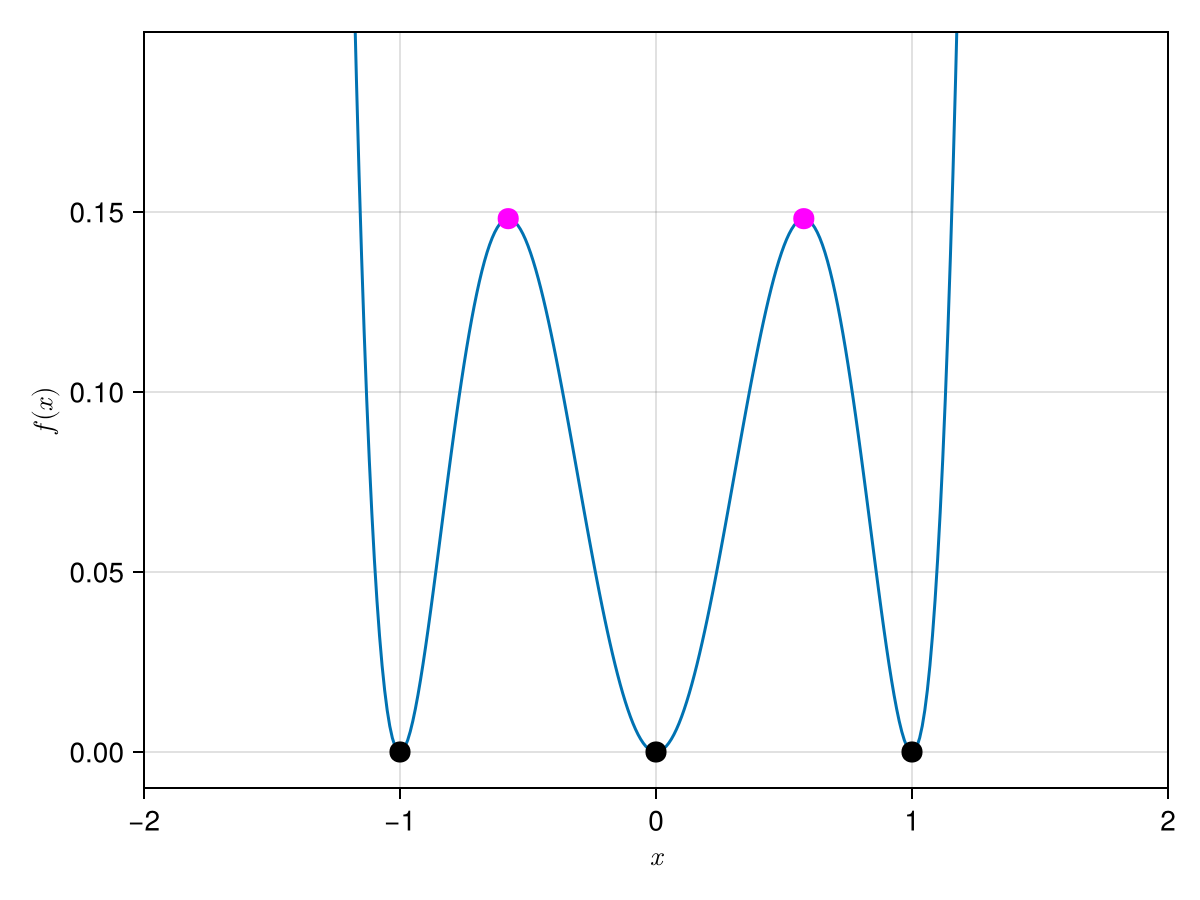

In [3]:
f(x)=(x[1]^3-x[1])^2;
xplot=-2:0.01:2
yplot=[f(x) for x in xplot];
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(-2,2,-0.01,0.2))
lines!(ax,xplot,yplot)
scatter!(ax,[0, -1, 1],f.([0, -1, 1]);color=:black,markersize=15)
scatter!(ax,[1/sqrt(3), -1/sqrt(3)],f.([1/sqrt(3), -1/sqrt(3)]);color=:magenta,markersize=15)
fig

 Similar to the previous notebook we set up and solve the optimization problem using  these three different functions `OptimizationFunction()`, `OptimizationProblem()` and `Optimization.solve()`.  Solving optimization problem will have the structure below as the previous notebook.

In the example below, we will use Newton method to find the minimum of a function

## Example 2.2.1 with Newton Method

In [4]:
x0=1.1*ones(1) #Define initial guess at x=1.1

optf = OptimizationFunction((x,p)->f(x), ADTypes.AutoZygote())
prob = OptimizationProblem(optf, x0) #first argument is the optimization function, second is the guess value and third is the parameter for optf()

vec_points=[]
sol = solve(prob,Optim.Newton();maxiters=20,callback=my_callback1D)
vec_points_new=copy(vec_points);

vec_points

┌ Warning: Verbosity toggle: incompatible_ad_backend 
│  The selected optimization algorithm requires second order derivatives, but `AutoZygote` ADtype was provided. So a `SecondOrder` with `AutoZygote` for inner and `AutoForwardDiff` for outer will be created, for choosing another pair an explicit `SecondOrder` ADtype is recommended.
└ @ OptimizationBase /Users/asho/.julia/packages/OptimizationBase/EAGYd/src/cache.jl:82


6-element Vector{Any}:
 Point1D(1.1, 0.053361000000000144)
 Point1D(1.0280305632885152, 0.003415267258623548)
 Point1D(1.0030198964574495, 3.681067047695686e-5)
 Point1D(1.0000402955734735, 6.495718151660929e-9)
 Point1D(1.0000000073050008, 2.1345214829850133e-16)
 Point1D(1.0000000000000002, 1.9721522630525295e-31)

* Note that it found the solution converges very quickly! It even stopped before we get to the 20 iterations we asked the program to perform!
* For the methods presented in the previous notebook, there are free parameters such as the learning rate $\alpha$ and momentum decay $\beta$ that you can tune to try and get a better/faster solution. For the Newton method, there is no free parameter that you can tune.
* Please also note that there is a warning from Julia that this method requires 2nd order derivatives indicating that this method needs computation of the 2nd derivatives.

In [5]:
sol.retcode

ReturnCode.Success = 1

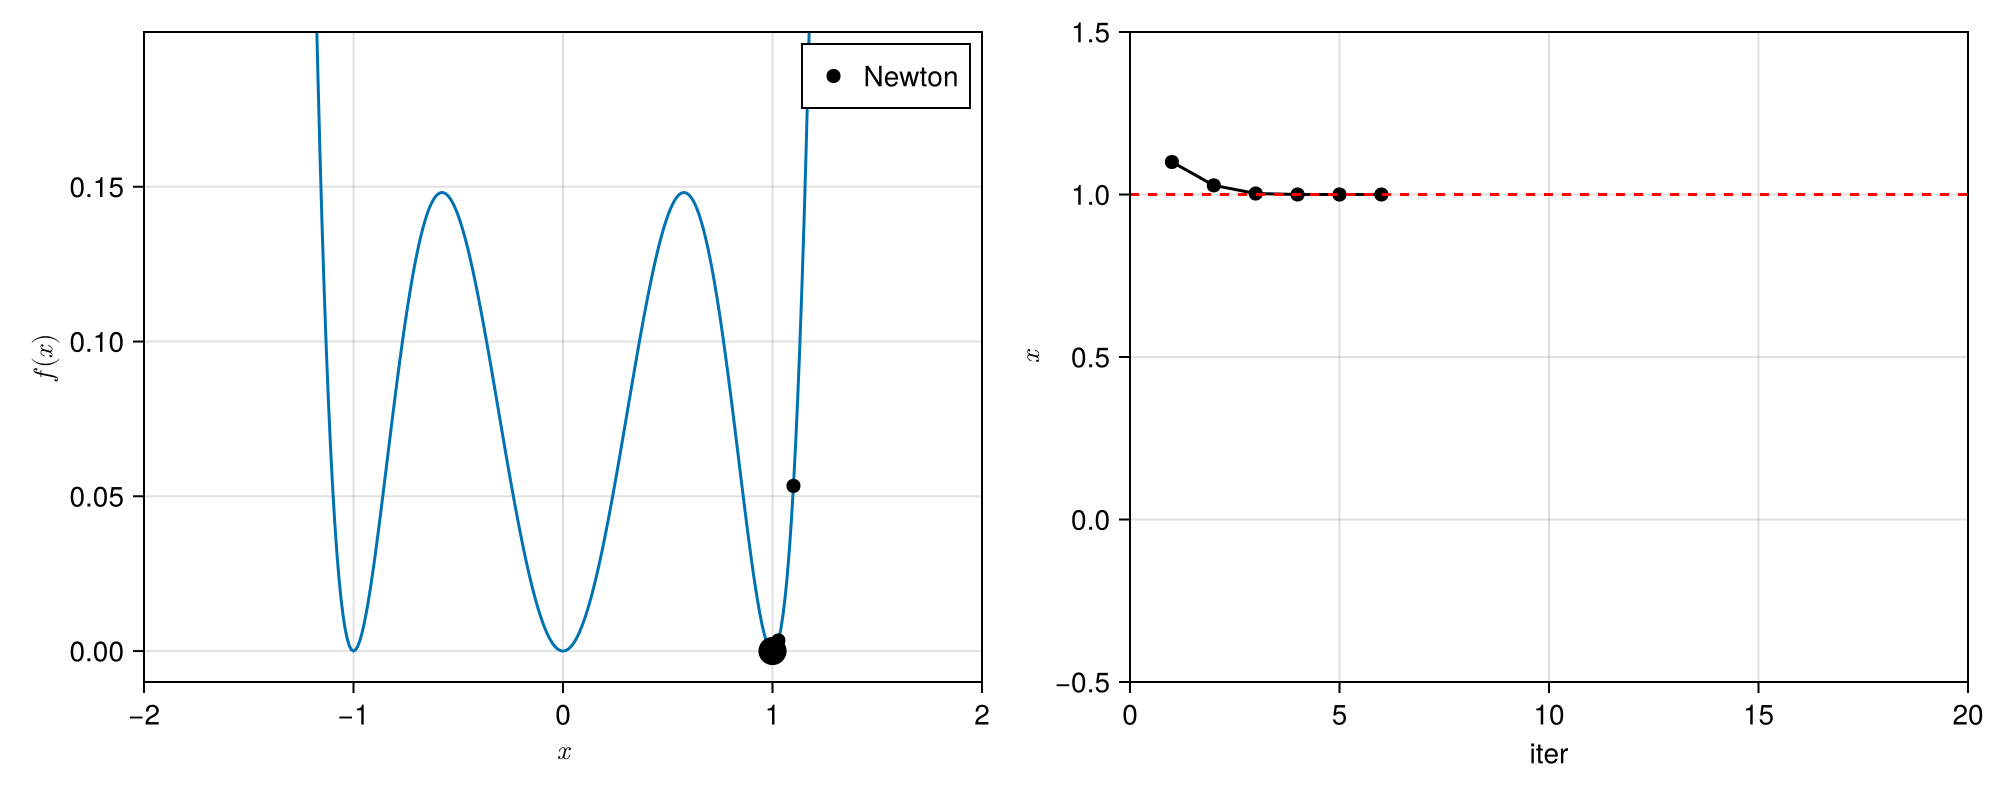

In [13]:
fig = Figure(size=(1000, 400))
ax1 = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(-2,2,-0.01,0.2))
ax2 = Axis(fig[1, 2], xlabel = "iter", ylabel = L"x",limits=(0,20,-0.5,1.5))
lines!(ax1,xplot,yplot)
scatter!(ax1,[1],[f(1)];markersize=20,color=:black)


scatter!(ax1,getproperty.(vec_points_new[:],:x),getproperty.(vec_points_new[:],:fvalue);markersize=10,color=:black,label="Newton")
scatter!(ax2,getproperty.(vec_points_new[:],:x);markersize=10,color=:black,label="Newton")
lines!(ax2,getproperty.(vec_points_new[:],:x);color=:black,label="")
hlines!(ax2,1.0, color=:red, linestyle=:dash) 
axislegend(ax1;position = :rt)

fig

Note that Newton method converges very quickly, only need 3 iterations for this example. 

<u>Exercise Ex01:</u> Try with different initial guess, $x=-0.5$.   Which minima do you think the Newton method will find?  You might want to execute the code `sol.retcode ` to see the convergence status

## Example 2.2.1 with BFGS method

Now we try the BFGS method.  The BFGS method converges quickly as well but it has a smart way of approximating the 2nd derivative and does not rely on knowing the exact values of the 2nd order derivatives.

In [14]:
vec_points

6-element Vector{Any}:
 Point1D(1.1, 0.053361000000000144)
 Point1D(-0.11506000000000194, 0.012890592069584383)
 Point1D(0.06981689348874687, 0.004826994907225923)
 Point1D(-0.0014937243273295958, 2.2312024094501164e-6)
 Point1D(2.894724921169824e-5, 8.379432355198667e-10)
 Point1D(-2.53345010816058e-10, 6.418369450538854e-20)

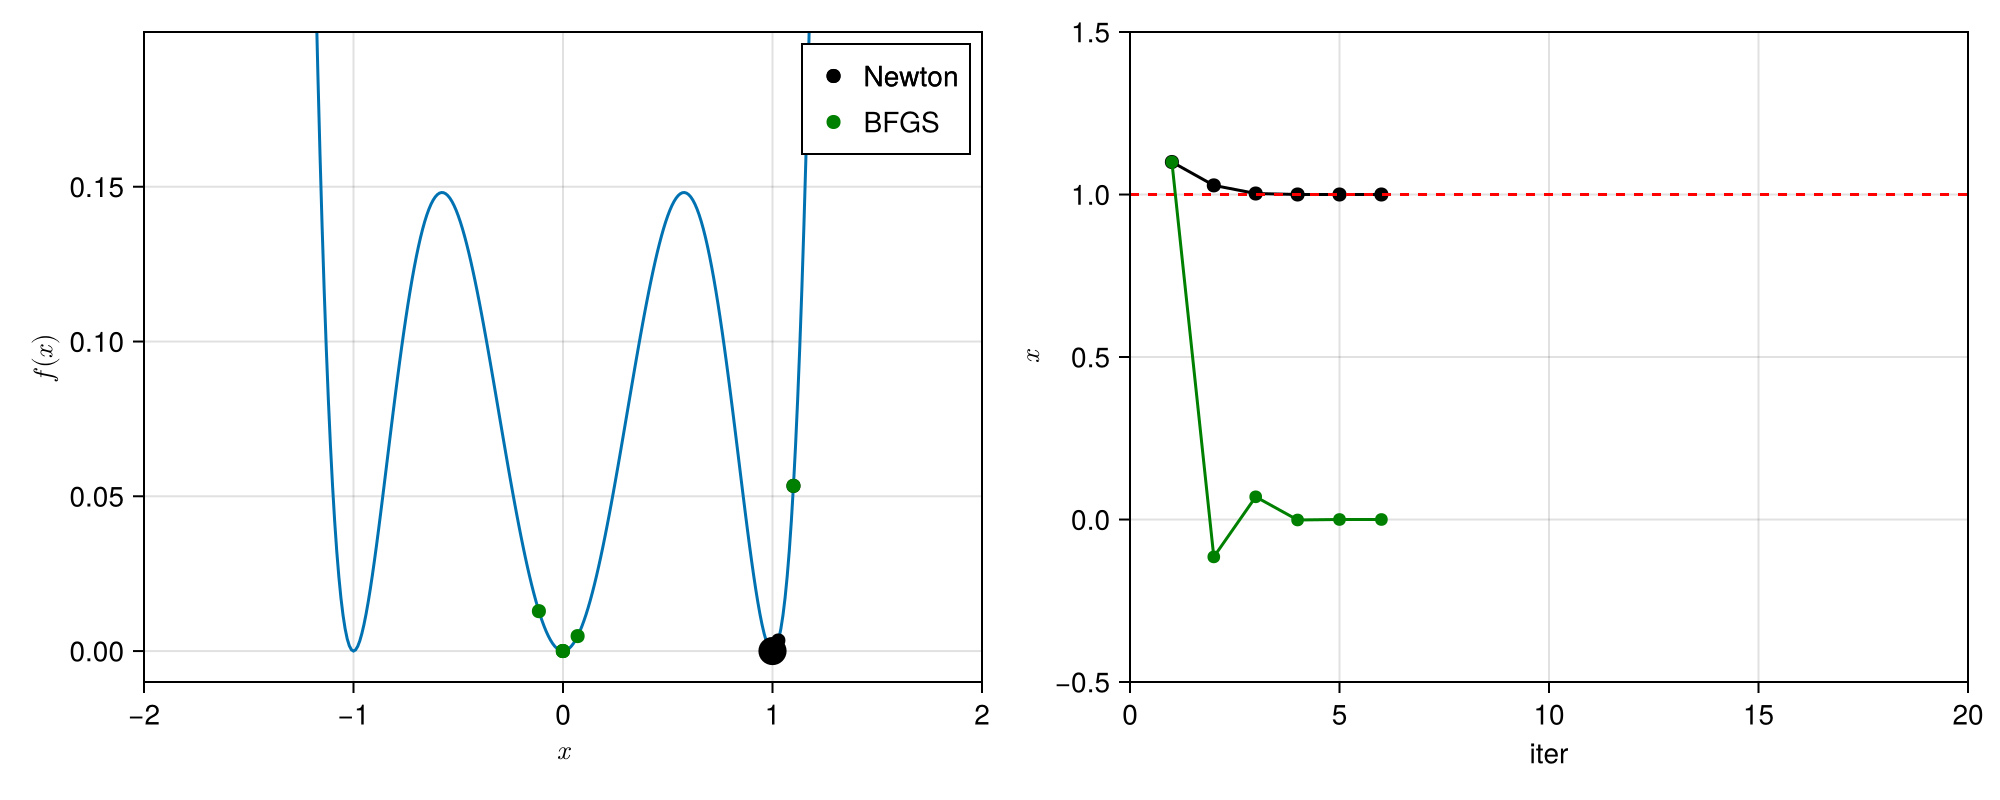

In [15]:
vec_points=[]
sol = solve(prob, Optim.BFGS();maxiters=20,callback=my_callback1D) #solve the problem and take 10 iterations. 
vec_points_bfgs=copy(vec_points);


scatter!(ax1,getproperty.(vec_points[:],:x),getproperty.(vec_points[:],:fvalue);markersize=10,color=:green,label="BFGS")
scatter!(ax2,getproperty.(vec_points[:],:x);color=:green,label="BFGS")
lines!(ax2,getproperty.(vec_points[:],:x);color=:green)
axislegend(ax1;position = :rt)

fig

* Even though we start with the same initial guess at $x=1.1$, both the Newton method and the BFGS method converges to a different local minimum!  This can happen.  The solution you find could be dependent on the method that you choose.  For this problem, and maybe for more complex problem, there is no unique solution.  There can be multiple solutions.

## Example 2.2.1 with LBFGS method 


LBFGS is a low storage version of the BFGS method.  Like BFGS, it approximates the second derivatives information instead of trying to compute it directly.

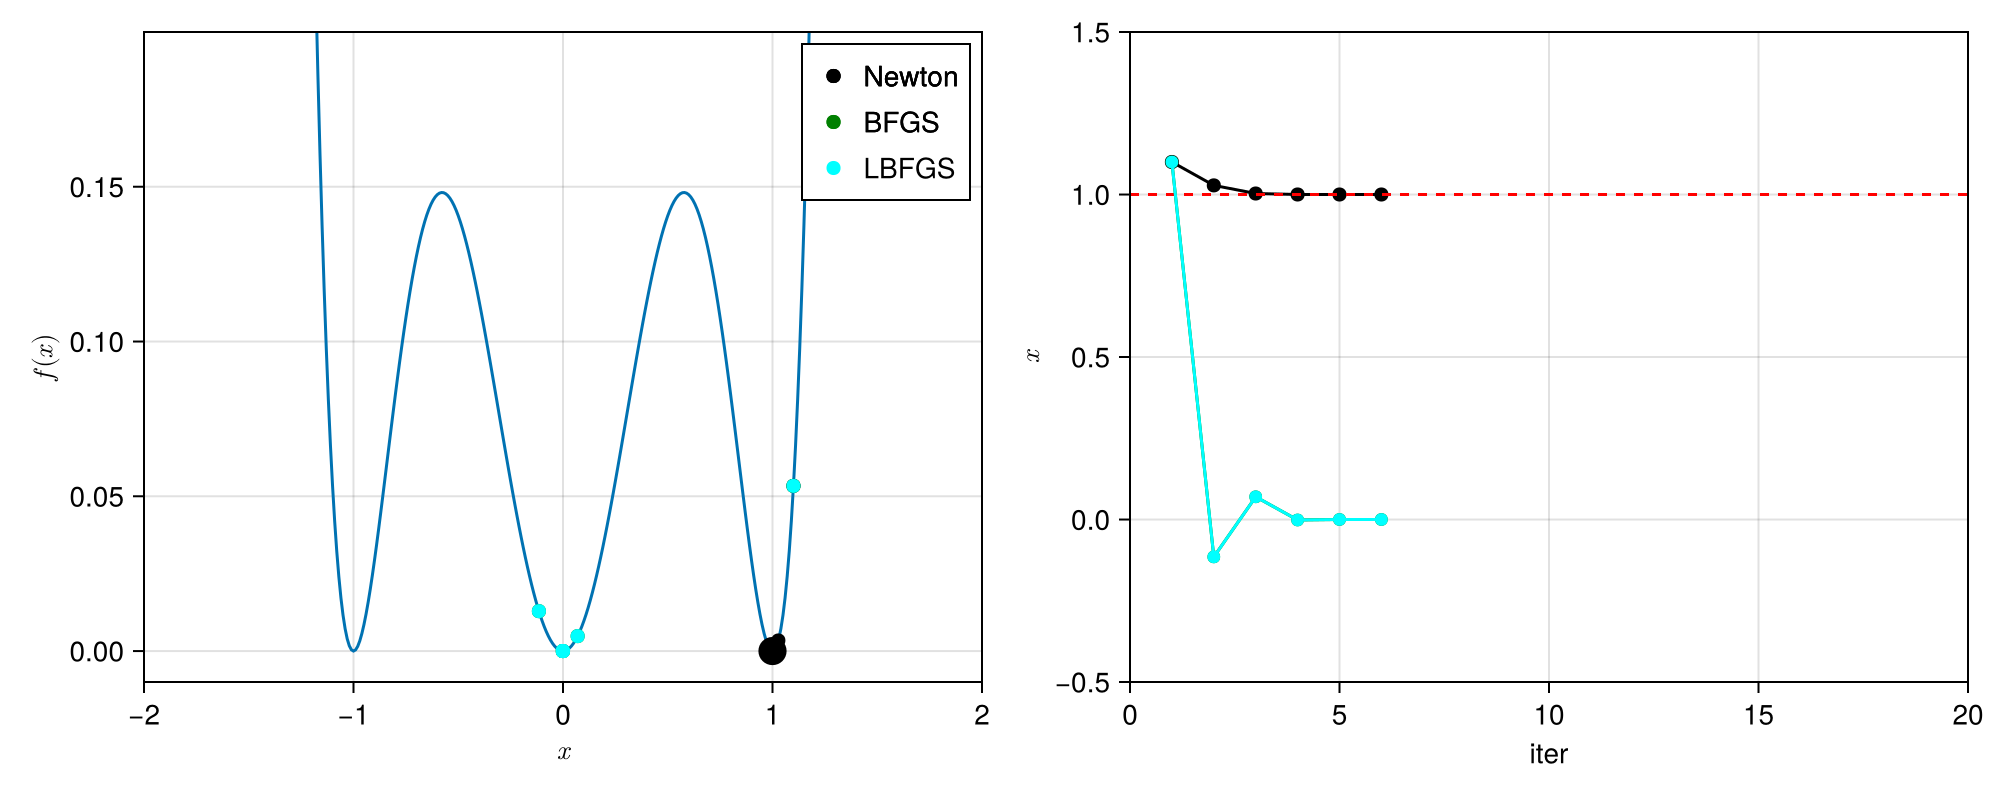

In [16]:
vec_points=[]
sol = solve(prob, Optim.LBFGS();maxiters=20,callback=my_callback1D) #solve the problem and take 10 iterations. 



scatter!(ax1,getproperty.(vec_points[:],:x),getproperty.(vec_points[:],:fvalue);markersize=10,color=:cyan,label="LBFGS")
scatter!(ax2,getproperty.(vec_points[:],:x);color=:cyan,label="LBFGS")
lines!(ax2,getproperty.(vec_points[:],:x);color=:cyan)
axislegend(ax1;position = :rt)

fig

Both BFGS and LBFGS have very similar solution paths.

---

# **Example 2.2.2**

Try "Simple" quadratic function from "An Introduction to  the Conjugate Gradient Method  Without the Agonizing Pain"  Edition 1 1  4  Jonathan Richard Shewchuk  August 4, 1994

$f(x_1,x_2)=\frac{3}{2}x_1^2+2x_1x_2+3x_2^2-2x_1+8x_2$

One can easily show that the minimum of this function is at $(x_1,x_2)=(2,-2)$

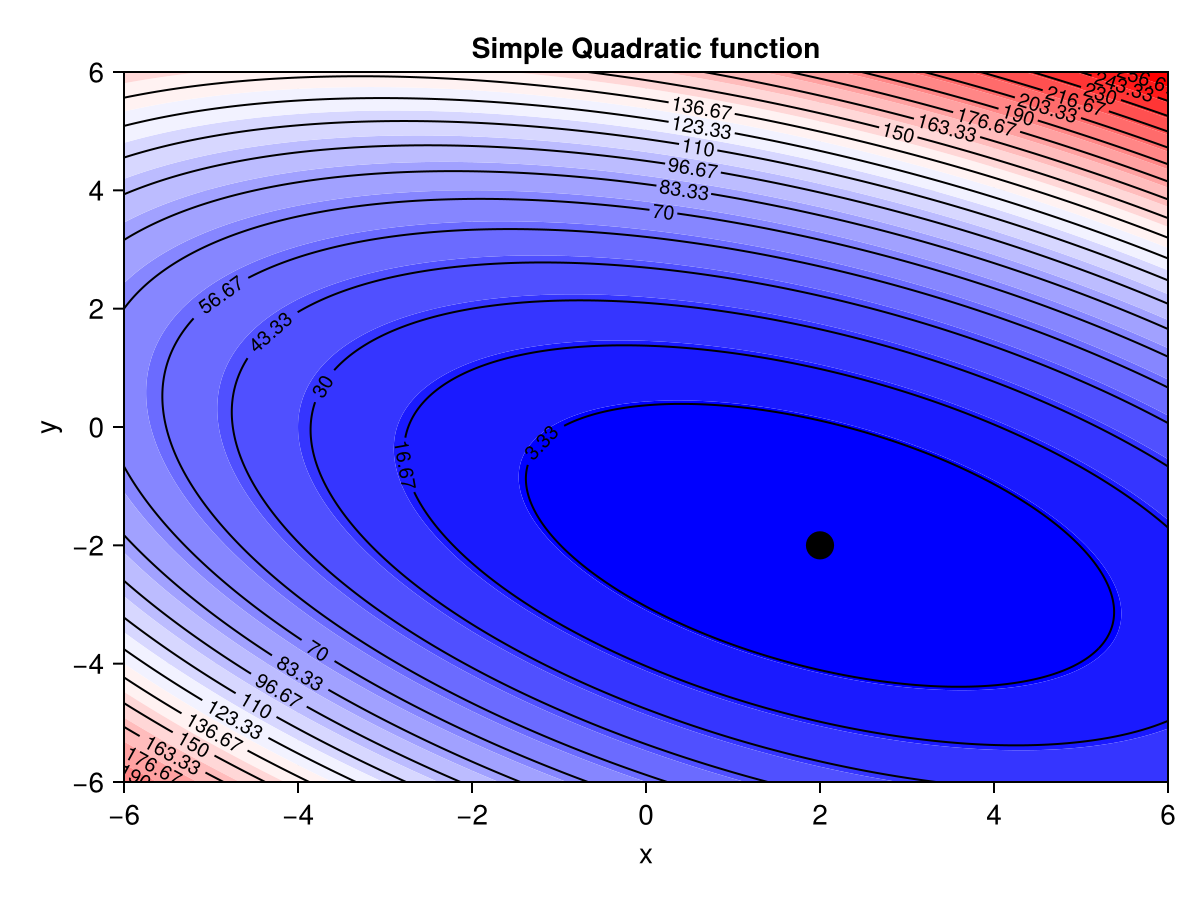

In [17]:
quad(x)=(3.0/2.0)*x[1]^2+2*x[1]*x[2]+3*x[2]^2-2*x[1]+8*x[2]

x1range=-6:0.02:6;
x2range=-6:0.02:6;
funcplot = [quad([x1,x2]) for x1 in x1range, x2 in x2range]
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "x", ylabel = "y",title = "Simple Quadratic function",limits=(-6,6.0,-6.0,6.0))
contourf!(ax,x1range,x2range,funcplot;  levels=20,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,color=:black)
scatter!(ax,[2],[-2];markersize=20,color=:black)
fig

┌ Warning: Verbosity toggle: missing_second_order_ad 
│  The selected optimization algorithm requires second order derivatives, but `SecondOrder` ADtype was not provided. So a `SecondOrder` with AutoForwardDiff() for both inner and outer will be created, this can be suboptimal and not work in some cases so an explicit `SecondOrder` ADtype is recommended.
└ @ OptimizationBase /Users/asho/.julia/packages/OptimizationBase/EAGYd/src/cache.jl:73


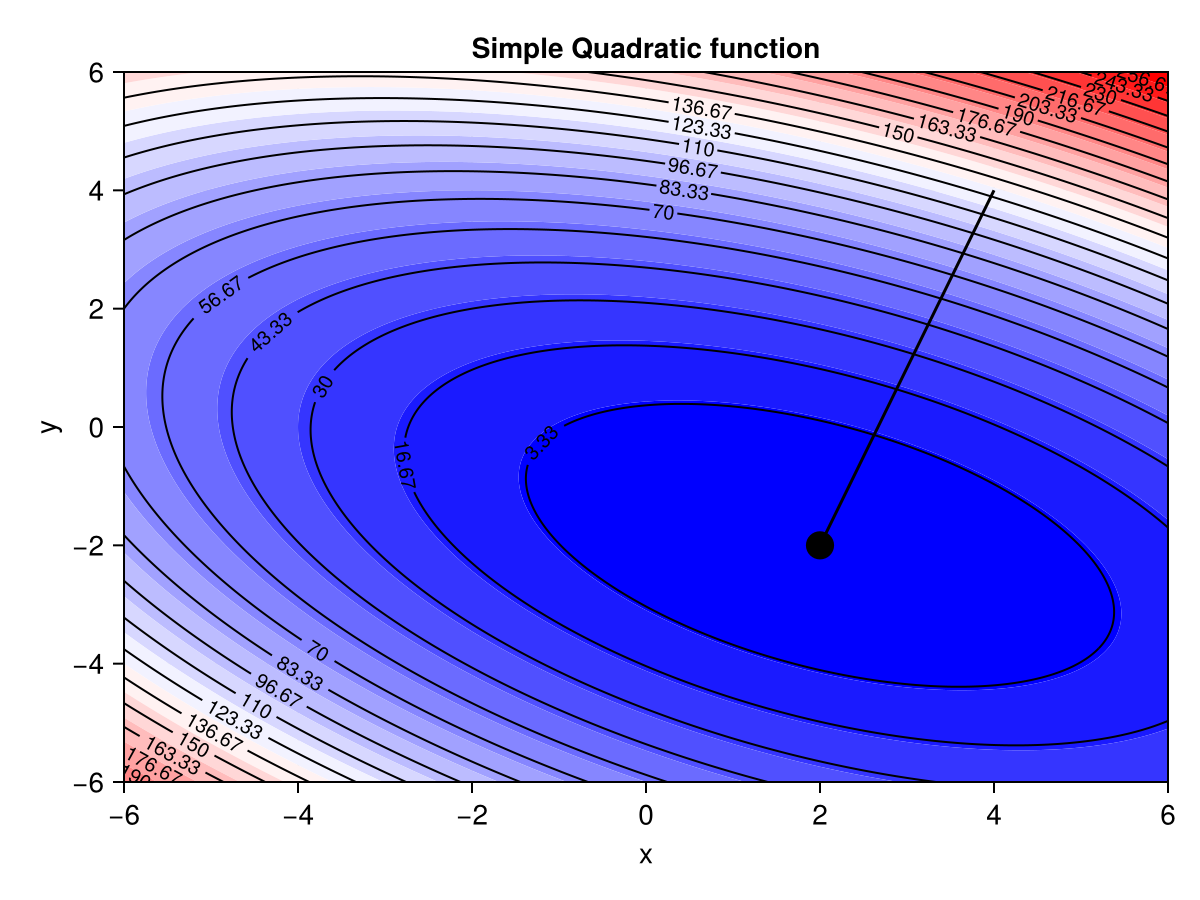

In [18]:
x0=4.0*ones(2) #Define initial guess

optf = OptimizationFunction((x,p)->quad(x), ADTypes.AutoForwardDiff())
prob = OptimizationProblem(optf, x0) #first argument is the optimization function, second is the guess value and third is the parameter for optf()

vec_points=[] #Define empty vector
sol = solve(prob,Optim.Newton();maxiters=20,callback=my_callback2D)
vec_points_new=copy(vec_points)

lines!(ax,getproperty.(vec_points[:],:x1),getproperty.(vec_points[:],:x2);color=:black,label="Newton")
fig

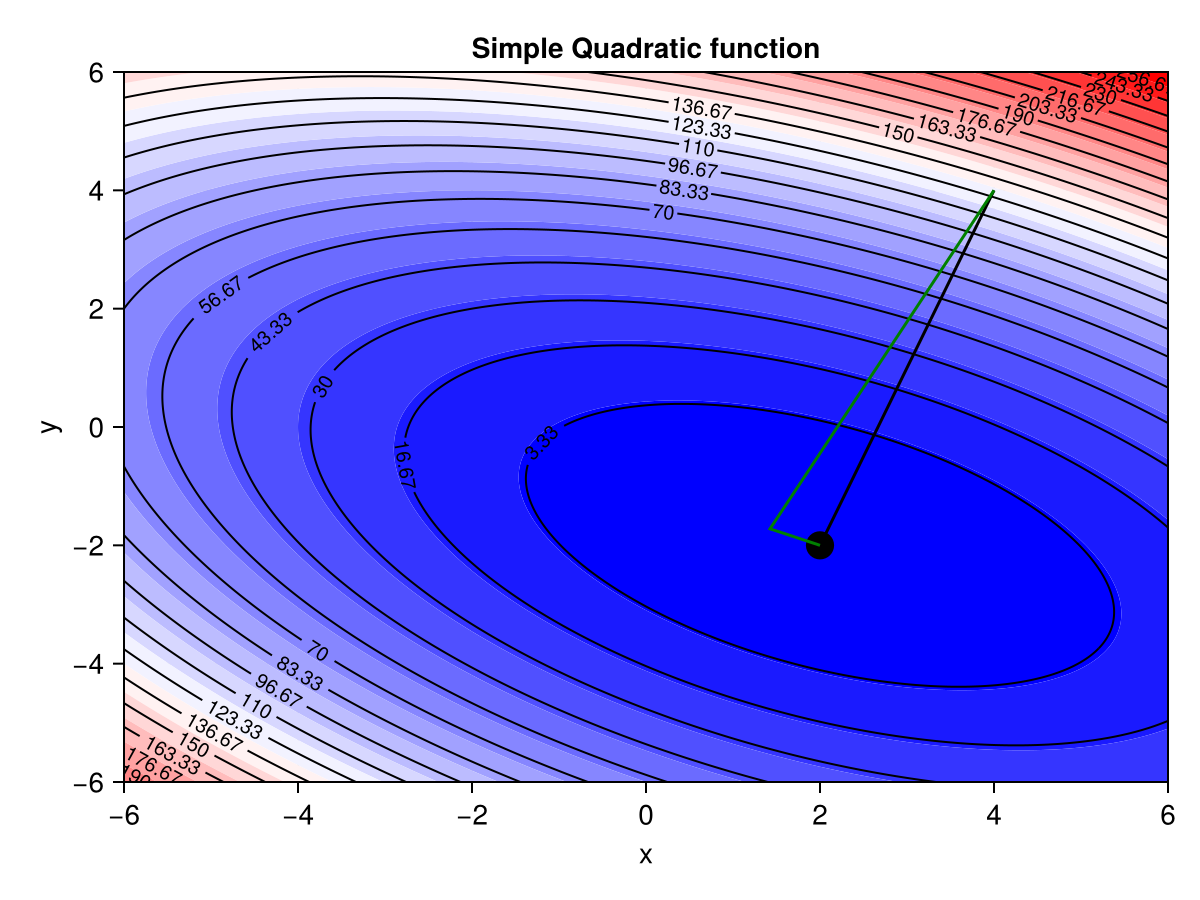

In [20]:
vec_points=[] #Define empty vector
sol = solve(prob,Optim.BFGS();maxiters=20,callback=my_callback2D)
vec_points_bfgs=copy(vec_points)

fig = Figure()
ax = Axis(fig[1, 1], xlabel = "x", ylabel = "y",title = "Simple Quadratic function",limits=(-6,6.0,-6.0,6.0))
contourf!(ax,x1range,x2range,funcplot;  levels=20,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,color=:black)
scatter!(ax,[2],[-2];markersize=20,color=:black)


lines!(ax,getproperty.(vec_points_new[:],:x1),getproperty.(vec_points_new[:],:x2);color=:black,label="Newton")
lines!(ax,getproperty.(vec_points_bfgs[:],:x1),getproperty.(vec_points_bfgs[:],:x2);color=:Green,label="BFGS")
fig

Now try LBFGS()

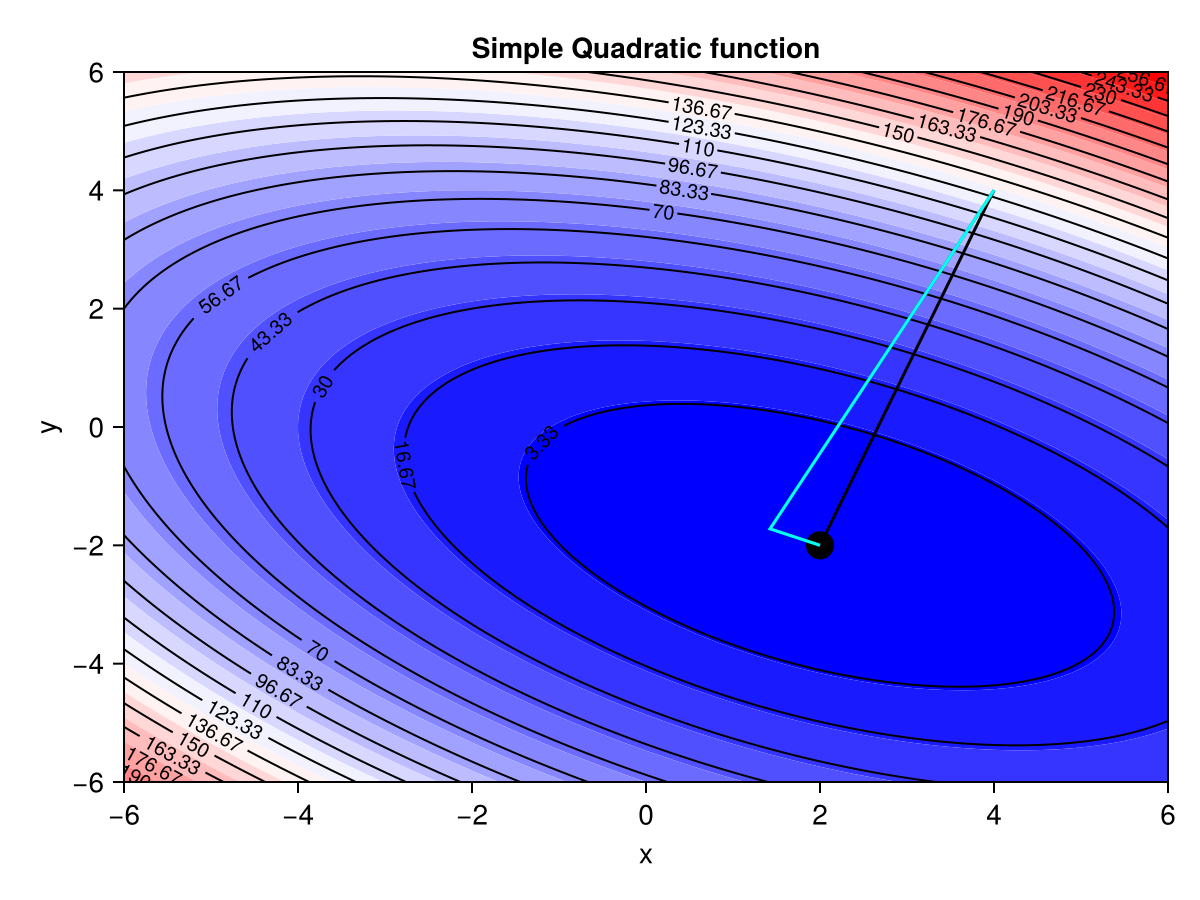

In [21]:
vec_points=[] #Define empty vector
sol = solve(prob,Optim.LBFGS();maxiters=20,callback=my_callback2D)
vec_points_lbfgs=copy(vec_points)

fig = Figure()
ax = Axis(fig[1, 1], xlabel = "x", ylabel = "y",title = "Simple Quadratic function",limits=(-6,6.0,-6.0,6.0))
contourf!(ax,x1range,x2range,funcplot;  levels=20,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,color=:black)
scatter!(ax,[2],[-2];markersize=20,color=:black)


lines!(ax,getproperty.(vec_points_new[:],:x1),getproperty.(vec_points_new[:],:x2);color=:black,label="Newton")
lines!(ax,getproperty.(vec_points_bfgs[:],:x1),getproperty.(vec_points_bfgs[:],:x2);color=:Green,label="BFGS")
lines!(ax,getproperty.(vec_points_lbfgs[:],:x1),getproperty.(vec_points_lbfgs[:],:x2);color=:cyan,label="LBFGS")
fig

---

# **Example 2.2.3**


Now we will try the minimum of the  Rosenbrock function.  Recall that the minimum of this function occur at $(x_1,x_2)= (1.0,1.0)$

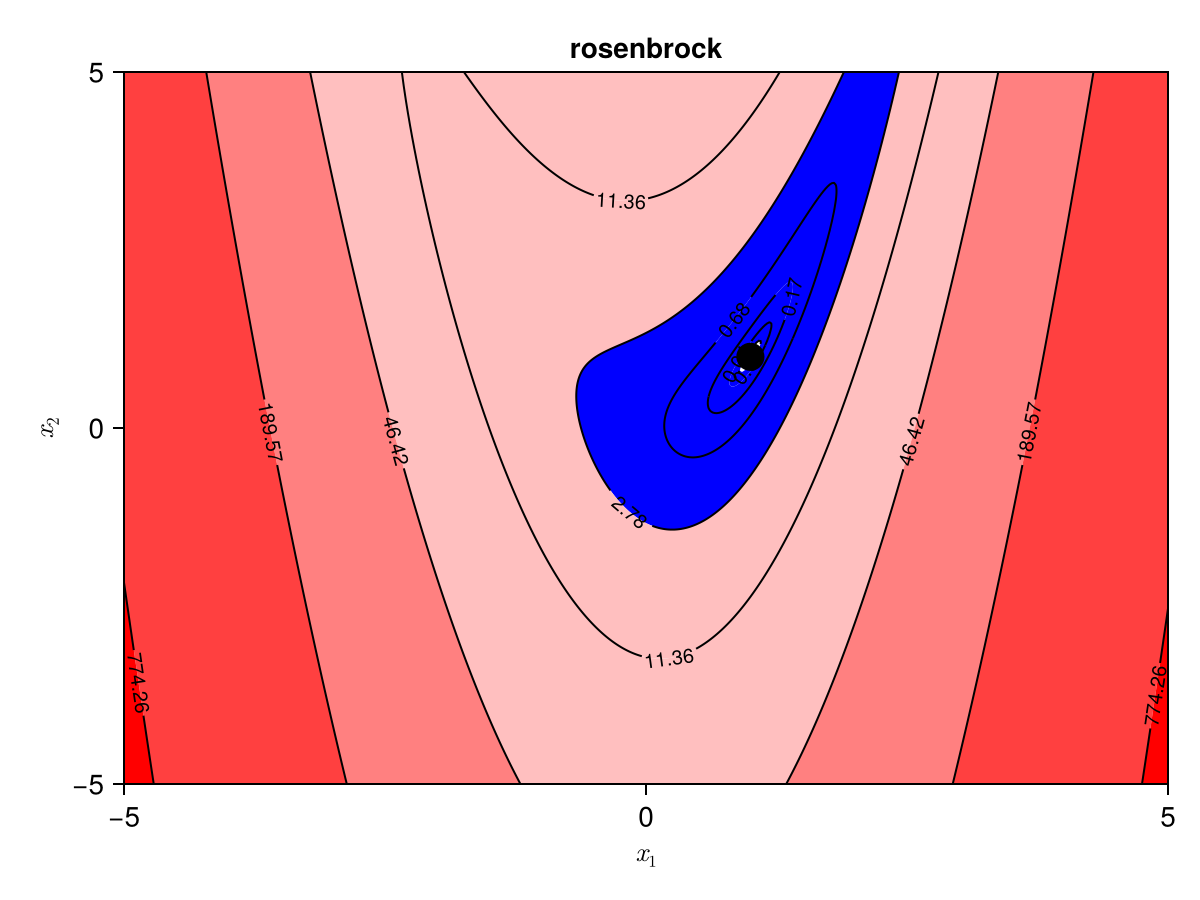

In [24]:
rosenbrock(x) = (1.0 - x[1])^2 + 1.0* (x[2] - x[1]^2)^2

x1range=-5:0.02:5;
x2range=-5:0.02:5;
funcplot = [rosenbrock([x1,x2]) for x1 in x1range, x2 in x2range]
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "rosenbrock",limits=(-5,5.0,-5.0,5.0))
levels = 10.0.^range(-2, 3.5; length=10)
contourf!(ax,x1range,x2range,funcplot; levels,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels,color=:black)
scatter!(ax,[1],[1];markersize=20,color=:black)
fig

┌ Warning: Verbosity toggle: incompatible_ad_backend 
│  The selected optimization algorithm requires second order derivatives, but `AutoZygote` ADtype was provided. So a `SecondOrder` with `AutoZygote` for inner and `AutoForwardDiff` for outer will be created, for choosing another pair an explicit `SecondOrder` ADtype is recommended.
└ @ OptimizationBase /Users/asho/.julia/packages/OptimizationBase/EAGYd/src/cache.jl:82


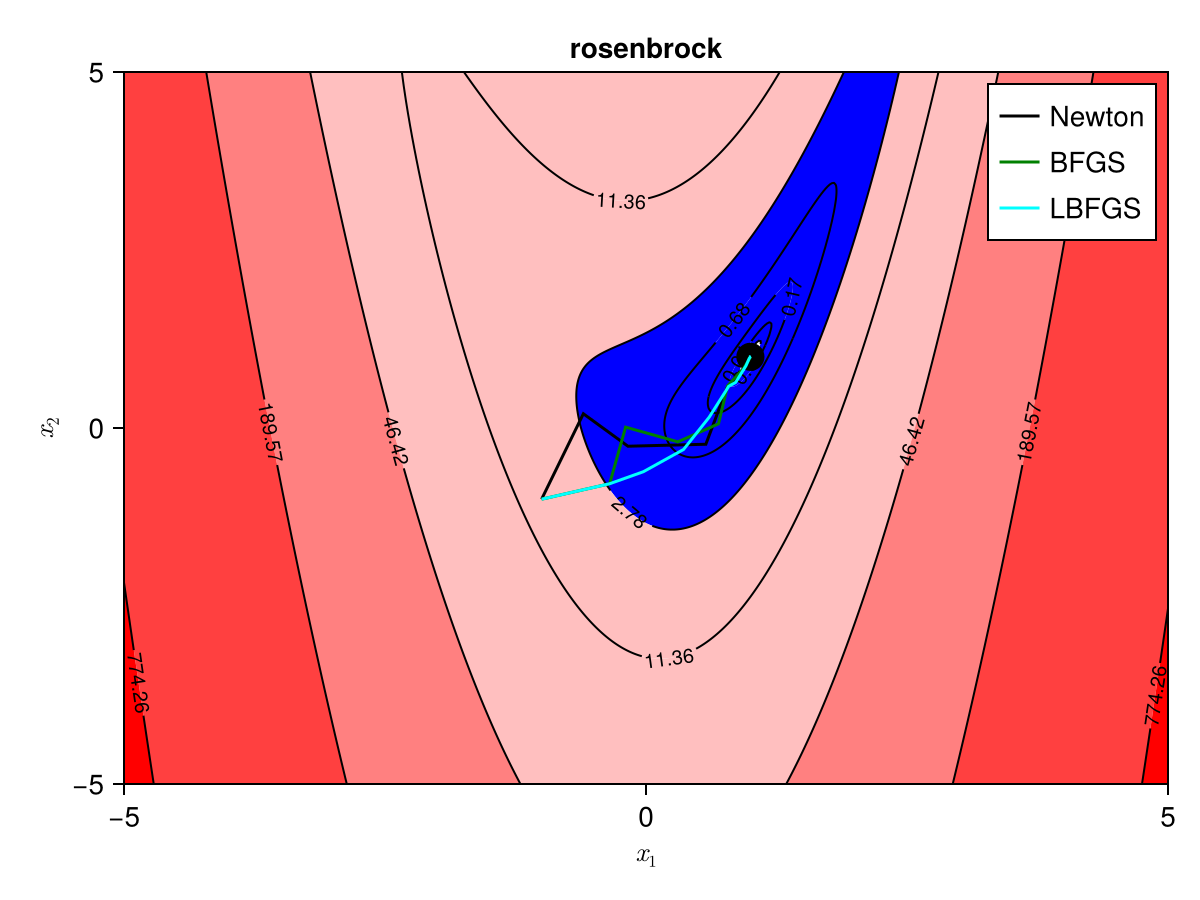

In [25]:
x0=-1.0*ones(2)
optf = OptimizationFunction((x,p)->rosenbrock(x), ADTypes.AutoZygote())
prob = OptimizationProblem(optf, x0)

vec_points=[] #Define empty vector
sol = solve(prob, Optim.Newton();maxiters=20,callback=my_callback2D)
vec_points_new=copy(vec_points)

vec_points=[] #Define empty vector
sol = solve(prob, Optim.BFGS();maxiters=20,callback=my_callback2D)
vec_points_bfgs=copy(vec_points)

vec_points=[] #Define empty vector
sol = solve(prob, Optim.LBFGS();maxiters=20,callback=my_callback2D)
vec_points_lbfgs=copy(vec_points)






fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "rosenbrock",limits=(-5,5.0,-5.0,5.0))
levels = 10.0.^range(-2, 3.5; length=10)
contourf!(ax,x1range,x2range,funcplot;  levels,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels,color=:black)
scatter!(ax,[1],[1];markersize=20,color=:black)

lines!(ax,getproperty.(vec_points_new[:],:x1),getproperty.(vec_points_new[:],:x2);color=:black,label="Newton")
lines!(ax,getproperty.(vec_points_bfgs[:],:x1),getproperty.(vec_points_bfgs[:],:x2);color=:Green,label="BFGS")
lines!(ax,getproperty.(vec_points_lbfgs[:],:x1),getproperty.(vec_points_lbfgs[:],:x2);color=:cyan,label="LBFGS")

axislegend(ax,  position = :rt,orientation = :vertical)

fig

All these methods converge within 20 iterations. You can print out more information about the solution process using the code below

In [26]:
println("Optimal parameters u:", sol.u)
println("Optimal objective value:", sol.objective)
println("Convergence status:",sol.retcode)

Optimal parameters u:[1.0000000000495348, 1.0000000001063707]
Optimal objective value:2.5070037722167512e-21
Convergence status:Success
